In [1]:
!pip -q install timm iterative-stratification tqdm

In [2]:
import os, math, random, time
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# ---------- Repro ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- Speed knobs ----------
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

Device: cuda


In [3]:
from google.colab import drive
drive.mount("/content/drive")

ZIP_PATH = "/content/drive/MyDrive/ImageCLEF/dev_concept.zip"
OUT_DIR  = "/content/data"
TASK_DIR = f"{OUT_DIR}/dev_concept"

assert os.path.exists(ZIP_PATH), f"Zip not found: {ZIP_PATH}"

# clean + extract
!apt-get -y -qq install p7zip-full > /dev/null

!rm -rf "{TASK_DIR}"
!mkdir -p "{OUT_DIR}"

print("⏳ Extracting with progress (7z) ...")
!7z x "{ZIP_PATH}" -o"{OUT_DIR}" -bsp1 -y
print("✅ Done. TASK_DIR:", TASK_DIR)
!ls -lah "{TASK_DIR}"

Mounted at /content/drive
⏳ Extracting with progress (7z) ...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,12 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (50657),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/ImageCLEF/                                           1 file, 9531160963 bytes (9090 MiB)

Extracting archive: /content/drive/MyDrive/ImageCLEF/dev_concept.zip
  3% 4096 Open               17% 20480 Open               --
Path = /content/drive/MyDrive/ImageCLEF/dev_concept.zip
Type = zip
Physical Size = 9531160963
64-bit = +

  0%      0% 174 - dev_concept/images/ImageCLEFmedical_Caption_2026_train_55933.jpg                                     

In [19]:
import re

IMG_DIR = f"{TASK_DIR}/images"
CONCEPTS_CSV = f"{TASK_DIR}/concepts.csv"
ATTR_CSV     = f"{TASK_DIR}/attribution.csv"

assert os.path.exists(IMG_DIR)
assert os.path.exists(CONCEPTS_CSV)

concepts_df = pd.read_csv(CONCEPTS_CSV)
print("concepts_df:", concepts_df.shape, concepts_df.columns.tolist())
print("images count:", len(os.listdir(IMG_DIR)))

def parse_cuis(s: str):
    if not isinstance(s, str):
        return []
    s = s.strip()
    if not s:
        return []
    # robust splitting: ; or | or space
    if ";" in s:
        parts = s.split(";")
    elif "|" in s:
        parts = s.split("|")
    else:
        parts = re.split(r"\s+", s)
    return [p.strip() for p in parts if p.strip()]

cui_lists = concepts_df["CUIs"].fillna("").astype(str).apply(parse_cuis)

# build global mapping (K)
all_cuis = sorted({c for lst in cui_lists for c in lst})
concept2idx = {c:i for i,c in enumerate(all_cuis)}
idx2concept = {i:c for c,i in concept2idx.items()}

N = len(concepts_df)
K = len(all_cuis)

print("N images:", N)
print("K concepts:", K)
print("Avg labels/image:", float(cui_lists.apply(len).mean()))

# build records: (img_path, img_id, label_indices)
records = []
missing = 0
for img_id, cu_l in zip(concepts_df["ID"].astype(str).tolist(), cui_lists.tolist()):
    img_path = os.path.join(IMG_DIR, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        missing += 1
        continue
    y_idx = [concept2idx[c] for c in cu_l]
    records.append((img_path, img_id, y_idx))

print("records:", len(records), "| missing images:", missing)

# support histogram (global GT)
support = np.zeros(K, dtype=np.int64)
for _, _, y_idx in records:
    for j in y_idx:
        support[j] += 1

print("Support stats:", "min", int(support.min()), "max", int(support.max()), "mean", float(support.mean()))

concepts_df: (116604, 2) ['ID', 'CUIs']
images count: 116604
N images: 116604
K concepts: 2646
Avg labels/image: 3.2206270796885184
records: 116604 | missing images: 0
Support stats: min 1 max 40992 mean 141.92668178382465


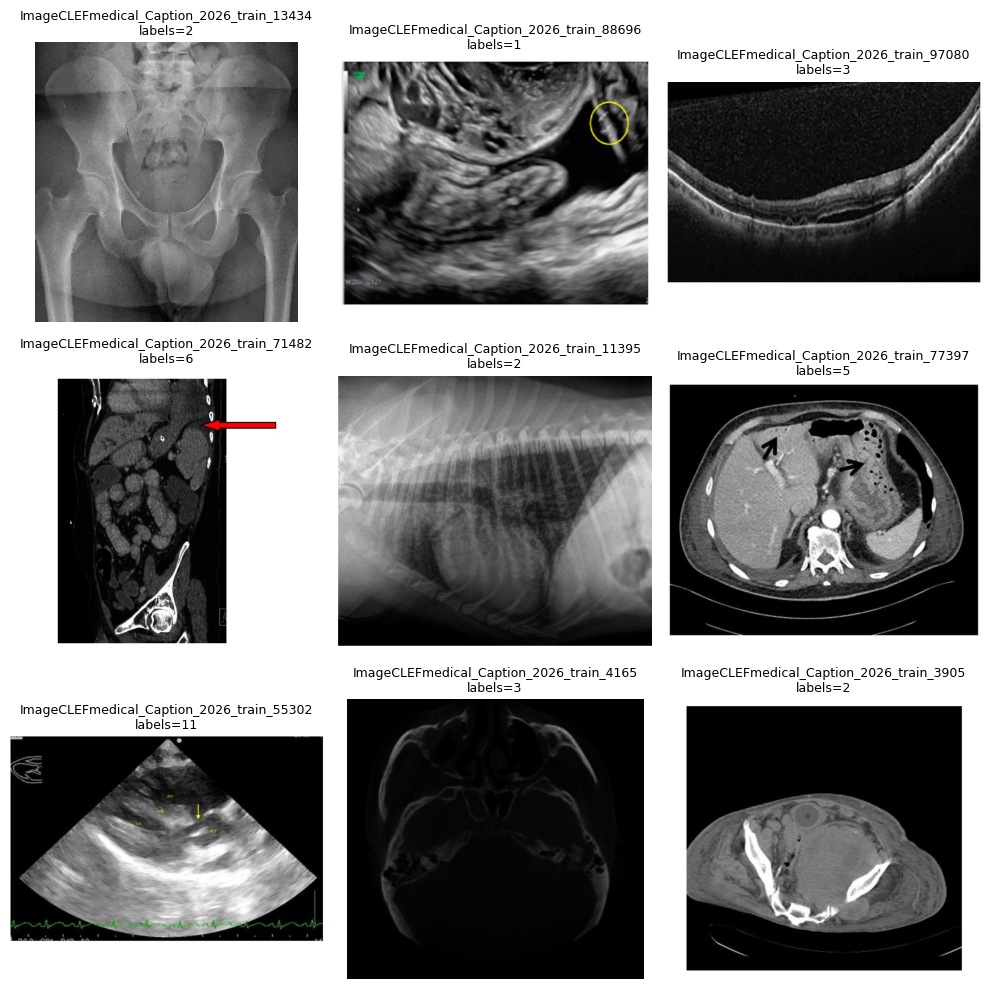

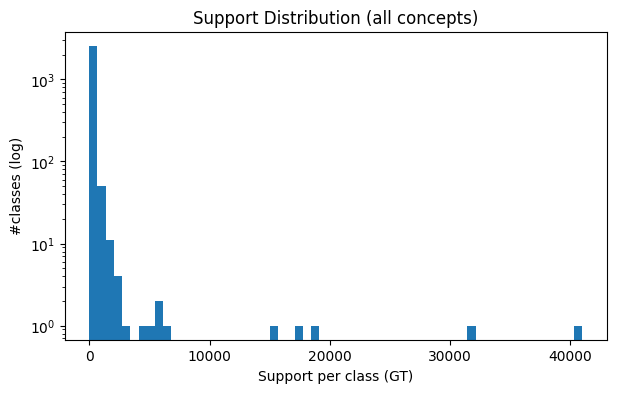

In [20]:
import matplotlib.pyplot as plt

# show 9 random images
sample = random.sample(records, 9)
plt.figure(figsize=(10,10))
for i,(p,img_id,y_idx) in enumerate(sample, start=1):
    img = Image.open(p).convert("RGB")
    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{img_id}\nlabels={len(y_idx)}", fontsize=9)
plt.tight_layout()
plt.show()

# support histogram (log scale)
plt.figure(figsize=(7,4))
plt.hist(support, bins=60)
plt.yscale("log")
plt.xlabel("Support per class (GT)")
plt.ylabel("#classes (log)")
plt.title("Support Distribution (all concepts)")
plt.show()

In [21]:
# Build dense Y only once for stratified split
# N x K uint8 is ~116k * 2646 ≈ 308MB -> OK on High-RAM
print("Building Y_dense (one-time) ...")
Y_dense = np.zeros((len(records), K), dtype=np.uint8)
for i, (_, _, y_idx) in enumerate(records):
    Y_dense[i, y_idx] = 1
print("Y_dense shape:", Y_dense.shape, "| MB:", Y_dense.nbytes/1024**2)

Building Y_dense (one-time) ...
Y_dense shape: (116604, 2646) | MB: 294.24112701416016


In [22]:
class ConceptDataset(Dataset):
    def __init__(self, recs, tfm):
        self.recs = recs
        self.tfm = tfm
    def __len__(self):
        return len(self.recs)
    def __getitem__(self, idx):
        path, img_id, y_idx = self.recs[idx]
        img = Image.open(path).convert("RGB")
        x = self.tfm(img)
        return x, np.array(y_idx, dtype=np.int64), img_id

def collate_fn(batch):
    xs, ys_idx, ids = zip(*batch)
    x = torch.stack(xs, dim=0)
    # build dense y [B,K] with scatter (fast)
    B = len(batch)
    y = torch.zeros((B, K), dtype=torch.float32)
    for i, idxs in enumerate(ys_idx):
        if len(idxs) > 0:
            y[i, idxs] = 1.0
    return x, y, ids

In [23]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.RandomRotation(5)], p=0.3),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

In [24]:
class AsymmetricLossStable(nn.Module):
    """
    ASL for multi-label (sigmoid). Good for long-tail.
    """
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        x_sigmoid = torch.sigmoid(logits)
        xs_pos = x_sigmoid
        xs_neg = 1.0 - x_sigmoid

        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # basic CE
        loss_pos = targets * torch.log(xs_pos.clamp(min=self.eps))
        loss_neg = (1 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss = loss_pos + loss_neg

        # asymmetric focusing
        pt = xs_pos * targets + xs_neg * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        w = torch.pow(1 - pt, gamma)
        loss *= w

        return -loss.mean()

In [25]:
import timm

class LabelEmbeddingHead(nn.Module):
    def __init__(self, n_labels, emb_dim):
        super().__init__()
        self.E = nn.Parameter(torch.randn(n_labels, emb_dim) * 0.02)
        self.b = nn.Parameter(torch.zeros(n_labels))

    def forward(self, h):  # h: [B,emb_dim]
        return h @ self.E.t() + self.b  # [B,n_labels]

class SwinMultiHead(nn.Module):
    def __init__(self, model_name, K, emb_dim, head_slices):
        """
        head_slices: dict of {head_name: np.array(label_indices)}
        """
        super().__init__()
        self.K = K
        self.head_slices = {k: torch.tensor(v, dtype=torch.long) for k,v in head_slices.items()}

        # backbone
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0)  # returns features
        feat_dim = self.backbone.num_features

        # shared projection
        self.proj = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, emb_dim),
            nn.GELU(),
            nn.Dropout(0.1),
        )

        # heads
        self.heads = nn.ModuleDict()
        for name, idxs in head_slices.items():
            self.heads[name] = LabelEmbeddingHead(len(idxs), emb_dim)

    def forward(self, x):
        f = self.backbone(x)      # [B,feat_dim]
        h = self.proj(f)          # [B,emb_dim]
        out = {}
        for name, head in self.heads.items():
            out[name] = head(h)   # logits per head
        return out

In [26]:
import copy

class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k].detach(), alpha=1.0 - self.decay)
            else:
                v.copy_(msd[k])

def build_optimizer(model, lr, wd):
    # 2-level LLRD: backbone lr smaller than heads/proj
    backbone_params = []
    head_params = []
    for n,p in model.named_parameters():
        if not p.requires_grad:
            continue
        if n.startswith("backbone."):
            backbone_params.append(p)
        else:
            head_params.append(p)

    return torch.optim.AdamW([
        {"params": backbone_params, "lr": lr*0.2, "weight_decay": wd},
        {"params": head_params,     "lr": lr,     "weight_decay": wd},
    ])

def lr_at_epoch(epoch, total_epochs, base_lr, warmup_epochs=2):
    # linear warmup then cosine
    if epoch <= warmup_epochs:
        return base_lr * (epoch / warmup_epochs)
    t = (epoch - warmup_epochs) / max(1, (total_epochs - warmup_epochs))
    return base_lr * 0.5 * (1 + math.cos(math.pi * t))

In [27]:
# ===== Cell 11 (REPLACE): Smart validation over threshold grid =====
import numpy as np
import torch
from tqdm import tqdm

EPS = 1e-12

THR_GRID = np.array([0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70], dtype=np.float32)

def _micro_from_totals(tp, pp, sp):
    fp = pp - tp
    fn = sp - tp
    micro = (2*tp) / (2*tp + fp + fn + EPS)
    P = tp / (tp + fp + EPS)
    R = tp / (tp + fn + EPS)
    return float(micro), float(P), float(R), float(pp)

@torch.no_grad()
def eval_epoch_grid(model, val_loader, thr_grid=THR_GRID):
    """
    Evaluates metrics for multiple thresholds in ONE pass.
    Returns:
      best_t, micro_best, macro_best, P_best, R_best, avg_pred_best,
      micro@0.5, macro@0.5, avg_pred@0.5
    """
    model.eval()
    T = len(thr_grid)
    thr_t = torch.tensor(thr_grid, device=device).view(T, 1, 1)

    # totals per threshold
    TP_tot = np.zeros(T, dtype=np.int64)
    PP_tot = np.zeros(T, dtype=np.int64)

    # per-label counts per threshold (for macro_nz)
    TP_l = np.zeros((T, K), dtype=np.int64)
    PP_l = np.zeros((T, K), dtype=np.int64)
    SP_l = np.zeros(K, dtype=np.int64)

    n_imgs = 0

    for x, y, _ in tqdm(val_loader, desc="Val(grid)", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).bool()   # [B,K]
        B = x.size(0)
        n_imgs += B

        out = model(x)  # dict: head->logits

        # accumulate per head
        for name, idxs_cpu in model.head_slices.items():
            idxs = idxs_cpu.to(device)
            y_h = y.index_select(1, idxs)  # [B, k_h]
            logits_h = out[name]
            prob_h = torch.sigmoid(logits_h).float()  # [B, k_h]

            # preds for all thresholds: [T,B,k_h]
            pred = (prob_h.unsqueeze(0) >= thr_t)

            # per-threshold totals
            pp_t = pred.sum(dim=(1,2)).to("cpu").numpy().astype(np.int64)
            tp_t = (pred & y_h.unsqueeze(0)).sum(dim=(1,2)).to("cpu").numpy().astype(np.int64)
            PP_tot += pp_t
            TP_tot += tp_t

            # per-label counts
            pp_l = pred.sum(dim=1).to("cpu").numpy().astype(np.int64)                       # [T, k_h]
            tp_l = (pred & y_h.unsqueeze(0)).sum(dim=1).to("cpu").numpy().astype(np.int64)  # [T, k_h]

            idxs_np = idxs_cpu.numpy()
            PP_l[:, idxs_np] += pp_l
            TP_l[:, idxs_np] += tp_l

            # support
            SP_l[idxs_np] += y_h.sum(dim=0).to("cpu").numpy().astype(np.int64)

            del pred, prob_h, logits_h, y_h

    SP_tot = int(SP_l.sum())

    # compute micro + macro per threshold
    micro_arr = np.zeros(T, dtype=np.float32)
    P_arr = np.zeros(T, dtype=np.float32)
    R_arr = np.zeros(T, dtype=np.float32)
    avg_pred_arr = np.zeros(T, dtype=np.float32)
    macro_arr = np.zeros(T, dtype=np.float32)

    keep = SP_l > 0
    for i in range(T):
        micro_i, P_i, R_i, pp_i = _micro_from_totals(TP_tot[i], PP_tot[i], SP_tot)
        micro_arr[i] = micro_i
        P_arr[i] = P_i
        R_arr[i] = R_i
        avg_pred_arr[i] = pp_i / max(1, n_imgs)

        # macro_nz at this threshold
        f1_l = (2.0 * TP_l[i]) / (PP_l[i] + SP_l + EPS)
        macro_arr[i] = float(f1_l[keep].mean()) if keep.any() else 0.0

    # pick best threshold: primary micro, tie macro
    best_idx = int(np.lexsort((macro_arr, micro_arr))[-1])
    best_t = float(thr_grid[best_idx])

    micro_best = float(micro_arr[best_idx])
    macro_best = float(macro_arr[best_idx])
    P_best = float(P_arr[best_idx])
    R_best = float(R_arr[best_idx])
    avg_best = float(avg_pred_arr[best_idx])

    # also report at 0.5 if exists
    idx_05 = int(np.argmin(np.abs(thr_grid - 0.50)))
    micro_05 = float(micro_arr[idx_05])
    macro_05 = float(macro_arr[idx_05])
    avg_05 = float(avg_pred_arr[idx_05])

    return best_t, micro_best, macro_best, P_best, R_best, avg_best, micro_05, macro_05, avg_05

In [32]:
# ===== Cell 12: FULL 3-FOLD TRAINING (direct) + AUTO-SAVE TO DRIVE =====
import math, torch, numpy as np, os, json, shutil
from tqdm import tqdm
from torch.utils.data import DataLoader, WeightedRandomSampler
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from google.colab import drive

# ------------------- FINAL TRAINING CONFIG -------------------
MODEL_NAME = "swin_base_patch4_window7_224"
EMB_DIM    = 256

BATCH_SIZE  = 32
GRAD_ACCUM  = 2          # effective BS = 64
EPOCHS      = 25
MIN_EPOCHS  = 12
PATIENCE    = 6
LR          = 1e-4
WD          = 1e-4

# lambdas (coverage-focused)
LAMBDAS = {
    "lt100":    4.0,
    "100_500":  2.0,
    "500_1000": 1.5,
    "gt1000":   1.0
}

ASL_PARAMS = {"gamma_neg": 2.0, "gamma_pos": 1.0, "clip": 0.0}
USE_EMA = True
NUM_WORKERS = 6

# smart patience deltas
MIN_DELTA_MICRO = 2e-4
MIN_DELTA_MACRO = 2e-4

# ------------------- AUTO-SAVE CONFIG -------------------
drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/ImageCLEF/Swin4Heads_3Fold_Final"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_progress_to_drive(fold_best_paths, fold_histories):
    for p in fold_best_paths:
        if os.path.exists(p):
            dst = os.path.join(SAVE_DIR, os.path.basename(p))
            shutil.copy2(p, dst)

    with open(f"{SAVE_DIR}/fold_histories.json", "w") as f:
        json.dump(fold_histories, f)

def lr_at_epoch(epoch, total_epochs, base_lr, warmup_epochs=2):
    # linear warmup then cosine
    if epoch <= warmup_epochs:
        return base_lr * (epoch / warmup_epochs)
    t = (epoch - warmup_epochs) / max(1, (total_epochs - warmup_epochs))
    return base_lr * 0.5 * (1 + math.cos(math.pi * t))

# ------------------- 3-FOLD SPLIT -------------------
mskf = MultilabelStratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
folds = list(mskf.split(np.zeros(len(records)), Y_dense))

fold_histories   = []
fold_best_paths  = []
fold_head_slices = []

# ------------------- TRAIN ALL 3 FOLDS DIRECTLY -------------------
for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
    print(f"\n===== Fold {fold}/3 =====")

    train_recs = [records[i] for i in tr_idx]
    val_recs   = [records[i] for i in va_idx]

    # Build head partitions from TRAIN fold
    head_slices, train_support = build_head_slices_from_train(tr_idx)
    fold_head_slices.append(head_slices)

    # Data
    ds_tr = ConceptDataset(train_recs, train_tfms)
    ds_va = ConceptDataset(val_recs,   val_tfms)

    weights = compute_sample_weights(train_recs, train_support)
    sampler = WeightedRandomSampler(
        torch.tensor(weights, dtype=torch.double),
        num_samples=len(weights),
        replacement=True
    )

    train_loader = DataLoader(
        ds_tr,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        ds_va,
        batch_size=256,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        collate_fn=collate_fn
    )

    # Model / Optim / Loss
    model = SwinMultiHead(MODEL_NAME, K, EMB_DIM, head_slices).to(device)
    criterion = AsymmetricLossStable(**ASL_PARAMS)
    optimizer = build_optimizer(model, LR, WD)
    scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
    ema = ModelEMA(model, decay=0.999) if USE_EMA else None

    best_path  = f"/content/best_fold{fold}.pt"
    best_micro = -1.0
    best_macro = -1.0
    bad = 0

    history = {
        "epoch": [],
        "lr": [],
        "train_loss": [],
        "val_best_t": [],
        "val_micro_best": [],
        "val_macro_best": [],
        "val_P_best": [],
        "val_R_best": [],
        "val_avg_pred_best": [],
        "val_microF1@0.5": [],
        "val_macro_nz@0.5": [],
        "val_avg_pred@0.5": []
    }

    for ep in range(1, EPOCHS + 1):
        # warmup+cosine LR + preserve backbone/head ratio
        lr_now = lr_at_epoch(ep, EPOCHS, LR, warmup_epochs=2)
        for g in optimizer.param_groups:
            if g["lr"] < LR:
                g["lr"] = lr_now * 0.2
            else:
                g["lr"] = lr_now

        model.train()
        optimizer.zero_grad(set_to_none=True)
        running = 0.0
        seen = 0

        pbar = tqdm(train_loader, desc=f"Fold {fold} Train Ep {ep}/{EPOCHS}", leave=False)
        for step, (x, y, _) in enumerate(pbar, start=1):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                out = model(x)
                loss = 0.0
                for name, idxs_cpu in model.head_slices.items():
                    idxs = idxs_cpu.to(device)
                    y_h = y.index_select(1, idxs)
                    logits_h = out[name]
                    loss_h = criterion(logits_h, y_h)
                    loss = loss + LAMBDAS[name] * loss_h

                loss = loss / GRAD_ACCUM

            if not torch.isfinite(loss):
                continue

            scaler.scale(loss).backward()

            if step % GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                if ema is not None:
                    ema.update(model)

            bs = x.size(0)
            running += float(loss.item()) * bs * GRAD_ACCUM
            seen += bs
            pbar.set_postfix(loss=running / max(1, seen), lr=lr_now)

        # flush remainder
        if (step % GRAD_ACCUM) != 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            if ema is not None:
                ema.update(model)

        train_loss = running / max(1, seen)

        # ---- SMART VALIDATION (best-t on grid) ----
        eval_model = ema.ema if ema is not None else model
        best_t, micro_best, macro_best, P_best, R_best, avg_best, micro_05, macro_05, avg_05 = eval_epoch_grid(eval_model, val_loader)

        history["epoch"].append(ep)
        history["lr"].append(lr_now)
        history["train_loss"].append(train_loss)
        history["val_best_t"].append(best_t)
        history["val_micro_best"].append(micro_best)
        history["val_macro_best"].append(macro_best)
        history["val_P_best"].append(P_best)
        history["val_R_best"].append(R_best)
        history["val_avg_pred_best"].append(avg_best)
        history["val_microF1@0.5"].append(micro_05)
        history["val_macro_nz@0.5"].append(macro_05)
        history["val_avg_pred@0.5"].append(avg_05)

        print(
            f"Fold {fold} | Ep {ep:02d}/{EPOCHS} | lr={lr_now:.2e} | loss={train_loss:.4f} | "
            f"BEST(t={best_t:.2f}) micro={micro_best:.4f} macro_nz={macro_best:.4f} "
            f"P={P_best:.4f} R={R_best:.4f} avg={avg_best:.2f} | "
            f"@0.5 micro={micro_05:.4f} macro_nz={macro_05:.4f} avg={avg_05:.2f}"
        )

        improved = (micro_best > best_micro + MIN_DELTA_MICRO) or (
            abs(micro_best - best_micro) <= MIN_DELTA_MICRO and macro_best > best_macro + MIN_DELTA_MACRO
        )

        if improved:
            best_micro = micro_best
            best_macro = macro_best
            bad = 0
            torch.save(eval_model.state_dict(), best_path)
        else:
            if ep >= MIN_EPOCHS:
                bad += 1
                if bad >= PATIENCE:
                    print(
                        f"Early stopping fold {fold} at epoch {ep}. "
                        f"Best micro={best_micro:.4f} (macro={best_macro:.4f})"
                    )
                    break

    fold_best_paths.append(best_path)
    fold_histories.append(history)

    # auto-save after each fold
    save_progress_to_drive(fold_best_paths, fold_histories)
    print(f"✅ Auto-saved fold {fold} progress to: {SAVE_DIR}")

print("\n✅ 3-Fold Training Done.")
print("Best checkpoints:", fold_best_paths)

# final safety save
save_progress_to_drive(fold_best_paths, fold_histories)
print("✅ Final auto-save completed:", SAVE_DIR)
!ls -lah "{SAVE_DIR}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===== Fold 1/3 =====


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

/tmp/ipykernel_1767/1801945190.py:112: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
Fold 1 Train Ep 1/25:   0%|          | 0/2430 [00:00<?, ?it/s]/tmp/ipykernel_1767/1801945190.py:154: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Fold 1 | Ep 01/25 | lr=5.00e-05 | loss=0.1188 | BEST(t=0.50) micro=0.5026 macro_nz=0.0028 P=0.9068 R=0.3477 avg=1.24 | @0.5 micro=0.5026 macro_nz=0.0028 avg=1.24


...

Fold 3 | Ep 13/25 | lr=5.34e-05 | loss=0.0415 | BEST(t=0.50) micro=0.5427 macro_nz=0.0069 P=0.8906 R=0.3903 avg=1.41 | @0.5 micro=0.5427 macro_nz=0.0069 avg=1.41


Fold 3 | Ep 14/25 | lr=4.66e-05 | loss=0.0401 | BEST(t=0.50) micro=0.5425 macro_nz=0.0070 P=0.8853 R=0.3910 avg=1.42 | @0.5 micro=0.5425 macro_nz=0.0070 avg=1.42


Fold 3 | Ep 15/25 | lr=3.98e-05 | loss=0.0391 | BEST(t=0.50) micro=0.5421 macro_nz=0.0072 P=0.8809 R=0.3915 avg=1.43 | @0.5 micro=0.5421 macro_nz=0.0072 avg=1.43


Fold 3 | Ep 16/25 | lr=3.33e-05 | loss=0.0382 | BEST(t=0.50) micro=0.5423 macro_nz=0.0073 P=0.8773 R=0.3924 avg=1.44 | @0.5 micro=0.5423 macro_nz=0.0073 avg=1.44


Fold 3 | Ep 17/25 | lr=2.70e-05 | loss=0.0373 | BEST(t=0.50) micro=0.5421 macro_nz=0.0074 P=0.8746 R=0.3928 avg=1.45 | @0.5 micro=0.5421 macro_nz=0.0074 avg=1.45
Early stopping fold 3 at epoch 17. Best micro=0.5445 (macro=0.0072)
✅ Auto-saved fold 3 progress to: /content/drive/MyDrive/ImageCLEF/Swin4Heads_3Fold_Final

✅ 3-Fold Training Done.
Best checkpoints: ['/content/best_fold1.pt', '/content/best_fold2.pt', '/content/best_fold3.pt']
✅ Final auto-save completed: /content/drive/MyDrive/ImageCLEF/Swin4Heads_3Fold_Final
total 1004M
-rw------- 1 root root 335M Apr 29 15:36 best_fold1.pt
-rw------- 1 root root 335M Apr 29 17:37 best_fold2.pt
-rw------- 1 root root 335M Apr 29 19:28 best_fold3.pt
-rw------- 1 root root  12K Apr 29 20:22 fold_histories.json


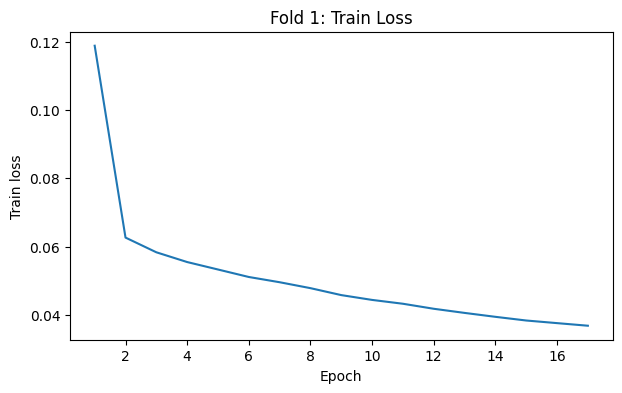

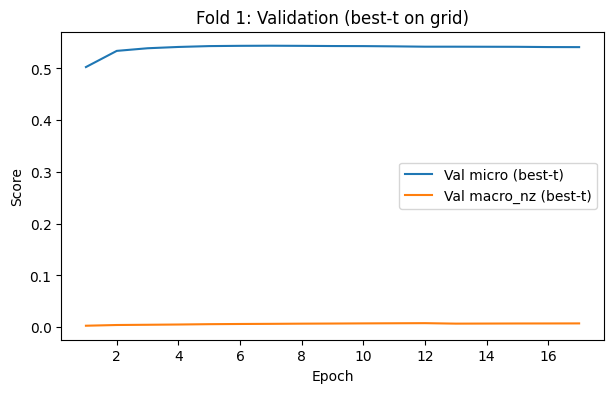

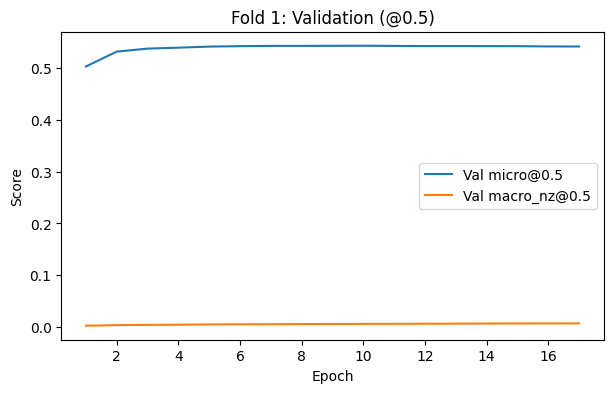

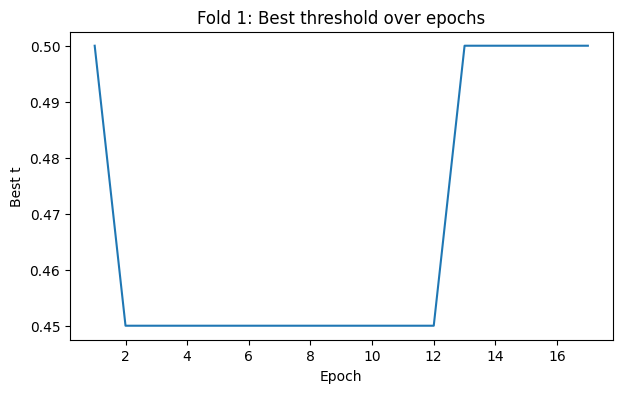

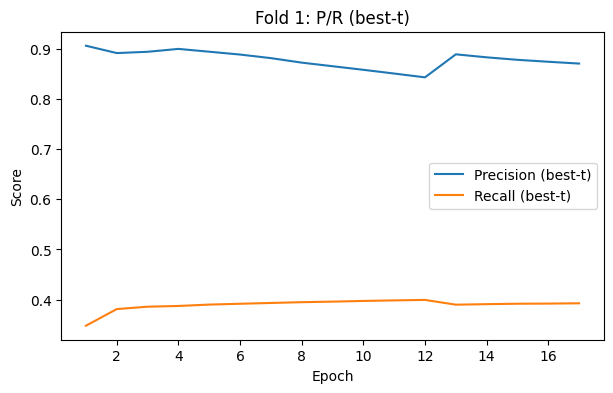

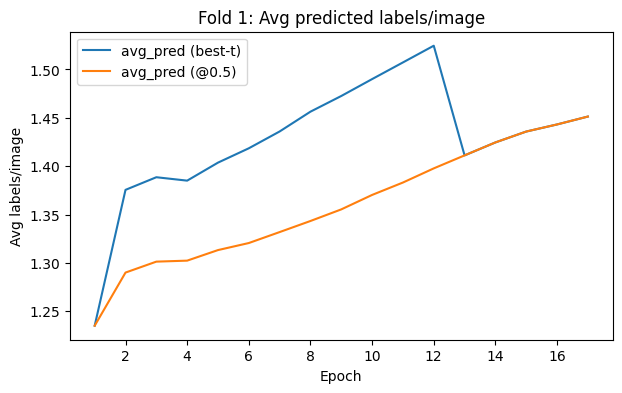

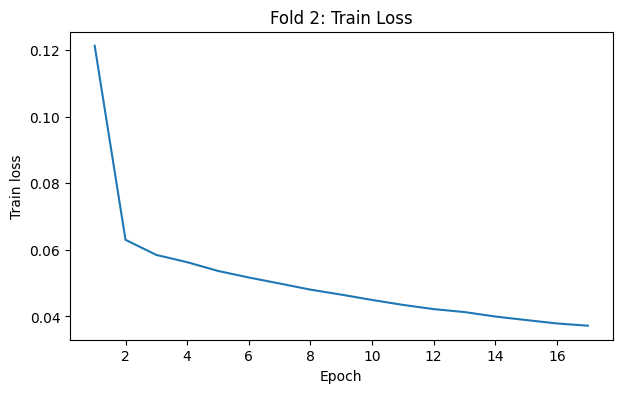

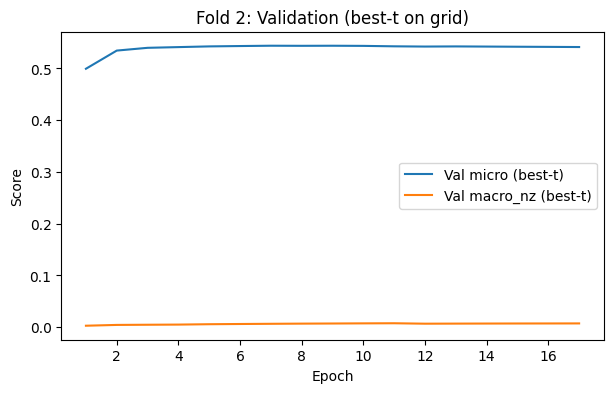

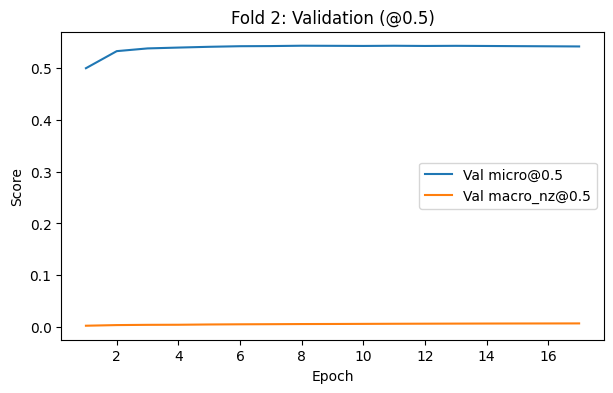

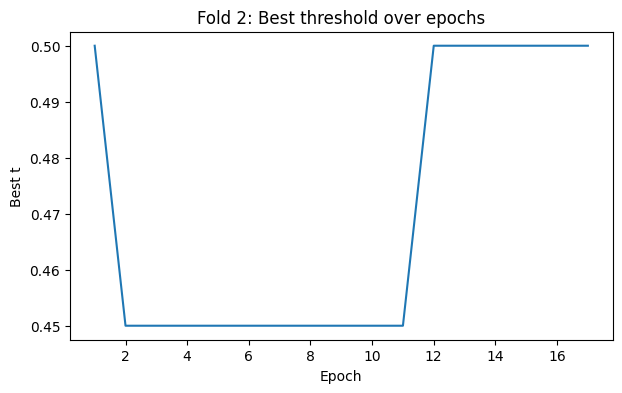

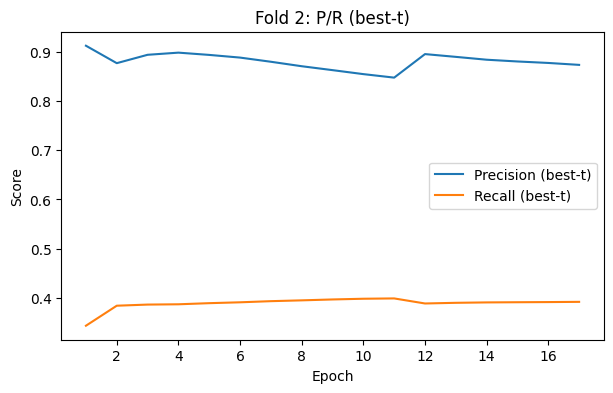

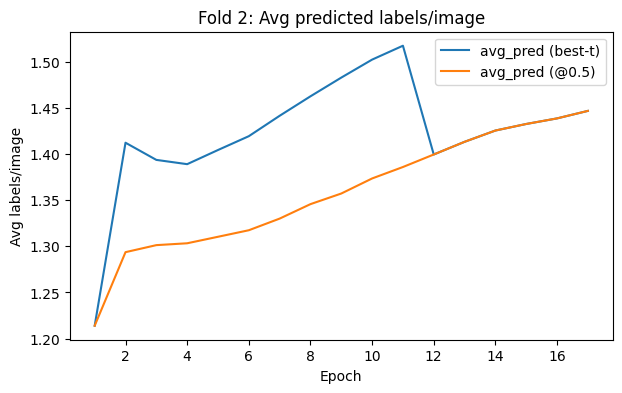

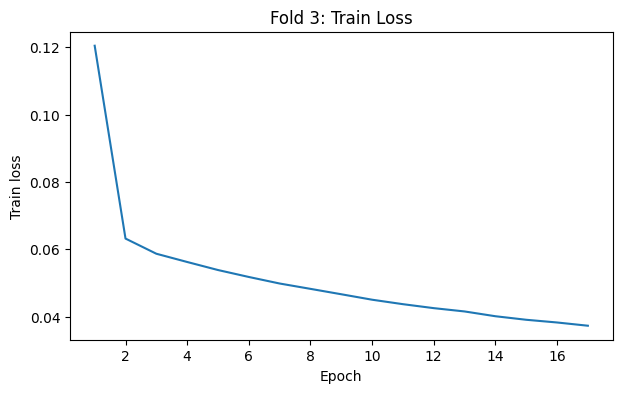

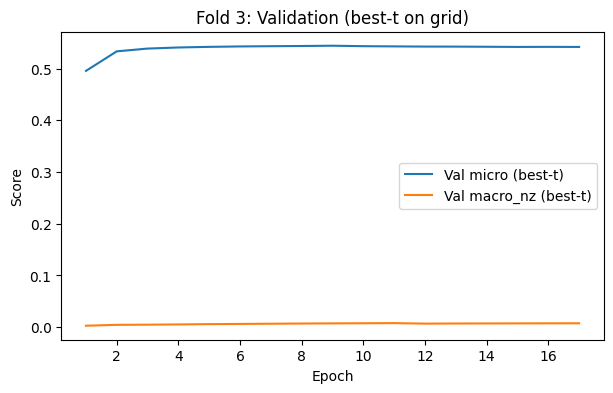

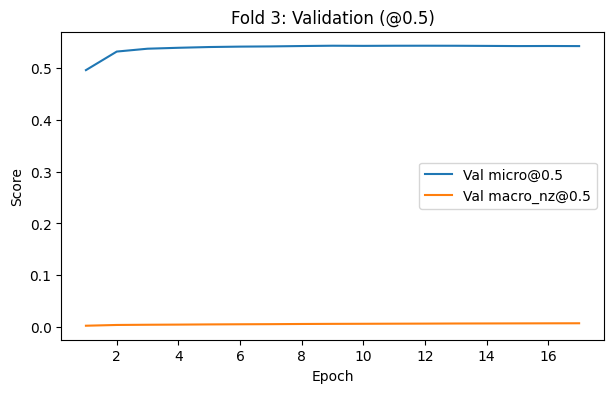

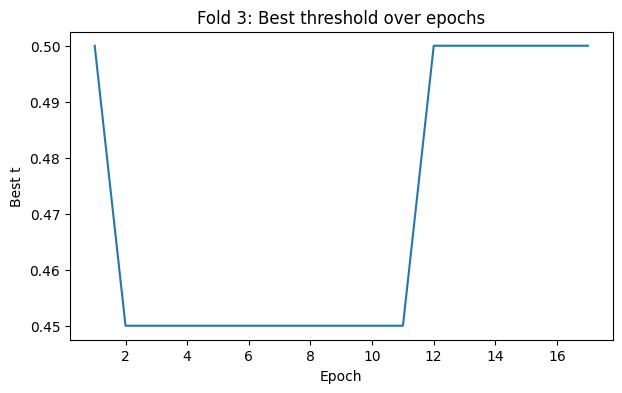

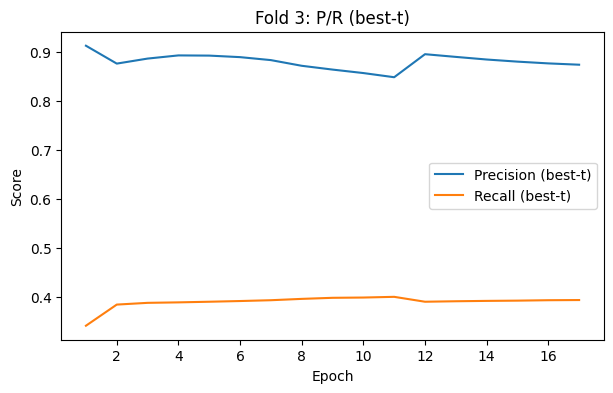

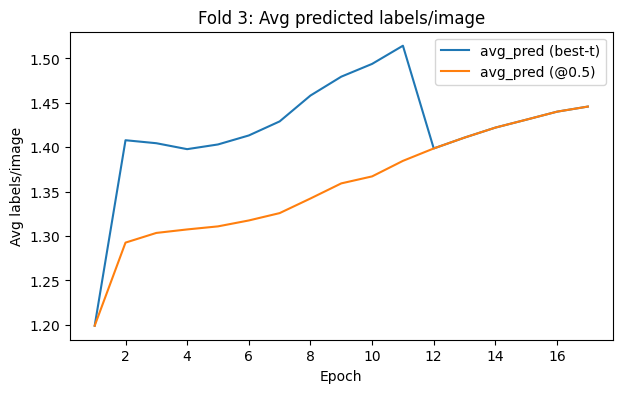

In [39]:
# ===== Cell 13: Plots per fold =====
import matplotlib.pyplot as plt

for i, h in enumerate(fold_histories, start=1):
    # Train loss
    plt.figure(figsize=(7,4))
    plt.plot(h["epoch"], h["train_loss"])
    plt.xlabel("Epoch"); plt.ylabel("Train loss")
    plt.title(f"Fold {i}: Train Loss")
    plt.show()

    # Val best
    plt.figure(figsize=(7,4))
    plt.plot(h["epoch"], h["val_micro_best"], label="Val micro (best-t)")
    plt.plot(h["epoch"], h["val_macro_best"], label="Val macro_nz (best-t)")
    plt.xlabel("Epoch"); plt.ylabel("Score")
    plt.title(f"Fold {i}: Validation (best-t on grid)")
    plt.legend()
    plt.show()

    # Val @0.5
    plt.figure(figsize=(7,4))
    plt.plot(h["epoch"], h["val_microF1@0.5"], label="Val micro@0.5")
    plt.plot(h["epoch"], h["val_macro_nz@0.5"], label="Val macro_nz@0.5")
    plt.xlabel("Epoch"); plt.ylabel("Score")
    plt.title(f"Fold {i}: Validation (@0.5)")
    plt.legend()
    plt.show()

    # best threshold curve
    plt.figure(figsize=(7,4))
    plt.plot(h["epoch"], h["val_best_t"])
    plt.xlabel("Epoch"); plt.ylabel("Best t")
    plt.title(f"Fold {i}: Best threshold over epochs")
    plt.show()

    # Precision/Recall at best-t
    plt.figure(figsize=(7,4))
    plt.plot(h["epoch"], h["val_P_best"], label="Precision (best-t)")
    plt.plot(h["epoch"], h["val_R_best"], label="Recall (best-t)")
    plt.xlabel("Epoch"); plt.ylabel("Score")
    plt.title(f"Fold {i}: P/R (best-t)")
    plt.legend()
    plt.show()

    # avg_pred
    plt.figure(figsize=(7,4))
    plt.plot(h["epoch"], h["val_avg_pred_best"], label="avg_pred (best-t)")
    plt.plot(h["epoch"], h["val_avg_pred@0.5"], label="avg_pred (@0.5)")
    plt.xlabel("Epoch"); plt.ylabel("Avg labels/image")
    plt.title(f"Fold {i}: Avg predicted labels/image")
    plt.legend()
    plt.show()

In [33]:
# ===== Cell 15: Build fold caches (Y/P) =====
import numpy as np
import torch
from numpy.lib.format import open_memmap
from tqdm import tqdm

@torch.no_grad()
def build_fold_cache(fold, va_idx, head_slices, best_path, bs=256, workers=6):
    val_recs = [records[i] for i in va_idx]
    ds_va = ConceptDataset(val_recs, val_tfms)
    val_loader = DataLoader(
        ds_va, batch_size=bs, shuffle=False,
        num_workers=workers, pin_memory=True,
        persistent_workers=True, prefetch_factor=2,
        collate_fn=collate_fn
    )

    model = SwinMultiHead(MODEL_NAME, K, EMB_DIM, head_slices).to(device)
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()

    Nval = len(val_recs)
    y_path = f"/content/fold{fold}_Y.npy"
    p_path = f"/content/fold{fold}_P.npy"

    Y_mem = open_memmap(y_path, mode="w+", dtype=np.uint8, shape=(Nval, K))
    P_mem = open_memmap(p_path, mode="w+", dtype=np.float32, shape=(Nval, K))

    pos = 0
    for x, y, _ in tqdm(val_loader, desc=f"Cache fold{fold}", leave=False):
        b = x.size(0)
        x = x.to(device, non_blocking=True)

        out = model(x)
        for name, idxs in model.head_slices.items():
            idxs_np = idxs.cpu().numpy()
            prob = torch.sigmoid(out[name]).float().cpu().numpy()
            P_mem[pos:pos+b, idxs_np] = prob

        Y_mem[pos:pos+b] = (y.cpu().numpy() > 0.5).astype(np.uint8)
        pos += b

    del Y_mem, P_mem
    print(f"✅ Saved fold {fold} cache:", y_path, p_path, "| Nval:", Nval)

for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
    build_fold_cache(fold, va_idx, fold_head_slices[fold-1], fold_best_paths[fold-1])

✅ Saved fold 1 cache: /content/fold1_Y.npy /content/fold1_P.npy | Nval: 38858


✅ Saved fold 2 cache: /content/fold2_Y.npy /content/fold2_P.npy | Nval: 38865


✅ Saved fold 3 cache: /content/fold3_Y.npy /content/fold3_P.npy | Nval: 38881


In [34]:
# ===== Cell 16: Precompute per-head stats for calibration =====
import numpy as np
import torch

EPS = 1e-12
THR_GRID = np.array([0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85], dtype=np.float32)

def precompute_head_stats(P_np, Y_np, idxs, thr_grid=THR_GRID, chunk=512):
    idxs = np.asarray(idxs, dtype=np.int64)
    P = P_np[:, idxs]
    Y = Y_np[:, idxs].astype(np.uint8)

    N, k = Y.shape
    sp_l = Y.sum(axis=0).astype(np.int64)
    sp_tot = int(sp_l.sum())

    T = len(thr_grid)
    TP_tot = np.zeros(T, dtype=np.int64)
    PP_tot = np.zeros(T, dtype=np.int64)
    TP_l   = np.zeros((T, k), dtype=np.int64)
    PP_l   = np.zeros((T, k), dtype=np.int64)

    thr_t = torch.tensor(thr_grid, device=device).view(T, 1, 1)

    for s in range(0, N, chunk):
        e = min(N, s+chunk)
        p = torch.tensor(np.array(P[s:e], dtype=np.float32), device=device)
        y = torch.tensor(np.array(Y[s:e], dtype=np.uint8), device=device).bool()

        pred = (p.unsqueeze(0) >= thr_t)

        PP_tot += pred.sum(dim=(1,2)).to("cpu").numpy().astype(np.int64)
        TP_tot += (pred & y.unsqueeze(0)).sum(dim=(1,2)).to("cpu").numpy().astype(np.int64)

        PP_l += pred.sum(dim=1).to("cpu").numpy().astype(np.int64)
        TP_l += (pred & y.unsqueeze(0)).sum(dim=1).to("cpu").numpy().astype(np.int64)

        del p, y, pred

    return {"idxs": idxs, "thr": thr_grid, "TP_tot": TP_tot, "PP_tot": PP_tot, "SP_tot": sp_tot,
            "TP_l": TP_l, "PP_l": PP_l, "SP_l": sp_l}

def precompute_fold(fold):
    Y = np.load(f"/content/fold{fold}_Y.npy", mmap_mode="r").astype(np.uint8)
    P = np.load(f"/content/fold{fold}_P.npy", mmap_mode="r").astype(np.float32)
    hs = fold_head_slices[fold-1]

    stats = {}
    for name, idxs in hs.items():
        print(f"Fold {fold}: precompute head {name} | labels={len(idxs)}")
        stats[name] = precompute_head_stats(P, Y, idxs, THR_GRID, chunk=512)
    return stats, Y.shape[0]

fold_stats = {}
fold_N = {}
for fold in [1,2,3]:
    st, nval = precompute_fold(fold)
    fold_stats[fold] = st
    fold_N[fold] = nval

print("✅ Precompute done.")

Fold 1: precompute head lt100 | labels=2336
Fold 1: precompute head 100_500 | labels=247
Fold 1: precompute head 500_1000 | labels=41
Fold 1: precompute head gt1000 | labels=22
Fold 2: precompute head lt100 | labels=2337
Fold 2: precompute head 100_500 | labels=246
Fold 2: precompute head 500_1000 | labels=41
Fold 2: precompute head gt1000 | labels=22
Fold 3: precompute head lt100 | labels=2337
Fold 3: precompute head 100_500 | labels=246
Fold 3: precompute head 500_1000 | labels=41
Fold 3: precompute head gt1000 | labels=22
✅ Precompute done.


In [35]:
# ===== Cell 17: Calibrate BOTH operating points =====
import numpy as np
import pandas as pd
import json

EPS = 1e-12
DELTA_MICRO = 0.005
TARGET_AVG = 3.22
MAX_AVG = 4.0

def micro_f1_from_totals(TP, PP, SP):
    return float((2*TP) / (PP + SP + EPS))

def eval_combo(fstats, choice_t_idx, NVAL):
    TP=PP=SP=0
    macro_sum=0.0; macro_cnt=0
    coverage=0

    for head, tidx in choice_t_idx.items():
        st = fstats[head]
        TP += int(st["TP_tot"][tidx])
        PP += int(st["PP_tot"][tidx])
        SP += int(st["SP_tot"])

        TP_l = st["TP_l"][tidx]
        PP_l = st["PP_l"][tidx]
        SP_l = st["SP_l"]

        f1 = (2.0 * TP_l) / (PP_l + SP_l + EPS)
        keep = SP_l > 0
        macro_sum += float(f1[keep].sum())
        macro_cnt += int(keep.sum())
        coverage += int(((TP_l > 0) & keep).sum())

    micro = micro_f1_from_totals(TP, PP, SP)
    macro_nz = macro_sum / max(1, macro_cnt)
    avg_pred = PP / max(1, NVAL)
    return float(micro), float(macro_nz), int(coverage), float(avg_pred)

def coord_descent_micro(fstats, heads, thr_grid, NVAL, iters=3):
    start = int(np.argmin(np.abs(thr_grid - 0.5)))
    choice = {h: start for h in heads}
    for _ in range(iters):
        for h in heads:
            best_local = None
            for tidx in range(len(thr_grid)):
                cand = dict(choice); cand[h] = tidx
                micro, macro, cov, avg = eval_combo(fstats, cand, NVAL)
                score = (micro, macro)
                if best_local is None or score > best_local[0]:
                    best_local = (score, tidx)
            choice[h] = best_local[1]
    micro, macro, cov, avg = eval_combo(fstats, choice, NVAL)
    return choice, micro, macro, cov, avg

def coord_descent_cov(fstats, heads, thr_grid, NVAL, micro_floor, iters=3):
    start = int(np.argmin(np.abs(thr_grid - 0.5)))
    choice = {h: start for h in heads}
    for _ in range(iters):
        for h in heads:
            best_local = None
            for tidx in range(len(thr_grid)):
                cand = dict(choice); cand[h] = tidx
                micro, macro, cov, avg = eval_combo(fstats, cand, NVAL)
                if micro < micro_floor or avg > MAX_AVG:
                    continue
                score = (macro, cov, micro, -abs(avg - TARGET_AVG))
                if best_local is None or score > best_local[0]:
                    best_local = (score, tidx)
            if best_local is not None:
                choice[h] = best_local[1]
    micro, macro, cov, avg = eval_combo(fstats, choice, NVAL)
    return choice, micro, macro, cov, avg

thr_micro = {}
thr_cov   = {}
rows = []

for fold in [1,2,3]:
    fstats = fold_stats[fold]
    heads = list(fstats.keys())
    thr_grid = THR_GRID
    NVAL = fold_N[fold]

    ch_m, micro_m, macro_m, cov_m, avg_m = coord_descent_micro(fstats, heads, thr_grid, NVAL)
    thr_micro[fold] = {h: float(thr_grid[ch_m[h]]) for h in heads}

    micro_floor = micro_m - DELTA_MICRO
    ch_c, micro_c, macro_c, cov_c, avg_c = coord_descent_cov(fstats, heads, thr_grid, NVAL, micro_floor)
    thr_cov[fold] = {h: float(thr_grid[ch_c[h]]) for h in heads}

    rows.append({
        "fold": fold,
        "micro_opt_microF1": micro_m,
        "micro_opt_macro_nz": macro_m,
        "micro_opt_coverage": cov_m,
        "micro_opt_avg_pred": avg_m,
        "cov_opt_microF1": micro_c,
        "cov_opt_macro_nz": macro_c,
        "cov_opt_coverage": cov_c,
        "cov_opt_avg_pred": avg_c,
        "micro_floor": micro_floor,
    })

    print(f"\nFold {fold}:")
    print(" Micro-opt thr:", thr_micro[fold])
    print(f" Micro-opt | micro={micro_m:.4f} macro_nz={macro_m:.4f} cov={cov_m} avg={avg_m:.2f}")
    print(" Coverage thr:", thr_cov[fold])
    print(f" Coverage | micro={micro_c:.4f} macro_nz={macro_c:.4f} cov={cov_c} avg={avg_c:.2f} (floor={micro_floor:.4f})")

df_cal = pd.DataFrame(rows)
display(df_cal)

print("\nMean micro-opt:", float(df_cal.micro_opt_microF1.mean()), "| macro_nz:", float(df_cal.micro_opt_macro_nz.mean()))
print("Mean coverage:", float(df_cal.cov_opt_microF1.mean()), "| macro_nz:", float(df_cal.cov_opt_macro_nz.mean()))

with open("/content/thresholds_micro_opt.json","w") as f:
    json.dump(thr_micro, f, indent=2)
with open("/content/thresholds_coverage_opt.json","w") as f:
    json.dump(thr_cov, f, indent=2)

print("✅ Saved thresholds JSON in /content/")


Fold 1:
 Micro-opt thr: {'lt100': 0.4000000059604645, '100_500': 0.4000000059604645, '500_1000': 0.44999998807907104, 'gt1000': 0.44999998807907104}
 Micro-opt | micro=0.5440 macro_nz=0.0069 cov=63 avg=1.45
 Coverage thr: {'lt100': 0.25, '100_500': 0.4000000059604645, '500_1000': 0.4000000059604645, 'gt1000': 0.4000000059604645}
 Coverage | micro=0.5392 macro_nz=0.0082 cov=80 avg=1.68 (floor=0.5390)

Fold 2:
 Micro-opt thr: {'lt100': 0.4000000059604645, '100_500': 0.44999998807907104, '500_1000': 0.44999998807907104, 'gt1000': 0.44999998807907104}
 Micro-opt | micro=0.5438 macro_nz=0.0071 cov=60 avg=1.48
 Coverage thr: {'lt100': 0.30000001192092896, '100_500': 0.3499999940395355, '500_1000': 0.4000000059604645, 'gt1000': 0.44999998807907104}
 Coverage | micro=0.5391 macro_nz=0.0096 cov=122 avg=1.65 (floor=0.5388)

Fold 3:
 Micro-opt thr: {'lt100': 0.44999998807907104, '100_500': 0.4000000059604645, '500_1000': 0.44999998807907104, 'gt1000': 0.44999998807907104}
 Micro-opt | micro=0.54

,fold,micro_opt_microF1,micro_opt_macro_nz,micro_opt_coverage,micro_opt_avg_pred,cov_opt_microF1,cov_opt_macro_nz,cov_opt_coverage,cov_opt_avg_pred,micro_floor
0,1,0.543988,0.006914,63,1.452571,0.539203,0.008178,80,1.675794,0.538988
1,2,0.543841,0.007064,60,1.482722,0.539097,0.009638,122,1.650019,0.538841
2,3,0.544587,0.007784,74,1.501788,0.540679,0.009927,122,1.646563,0.539587



Mean micro-opt: 0.5441387218390389 | macro_nz: 0.007253841496774063
Mean coverage: 0.5396596286868108 | macro_nz: 0.009247827097032165
✅ Saved thresholds JSON in /content/


In [36]:
import os, shutil

SAVE_DIR = "/content/drive/MyDrive/ImageCLEF/Swin4Heads_3Fold_Final"
os.makedirs(SAVE_DIR, exist_ok=True)

to_copy = [
    "/content/fold1_Y.npy", "/content/fold1_P.npy",
    "/content/fold2_Y.npy", "/content/fold2_P.npy",
    "/content/fold3_Y.npy", "/content/fold3_P.npy",
    "/content/thresholds_micro_opt.json",
    "/content/thresholds_coverage_opt.json",
]

for p in to_copy:
    if os.path.exists(p):
        shutil.copy2(p, os.path.join(SAVE_DIR, os.path.basename(p)))
        print("✅ copied:", p)
    else:
        print("⚠️ missing:", p)

!ls -lah "{SAVE_DIR}" | egrep "fold[123]_[YP]\.npy|thresholds_.*json|best_fold|fold_histories"

✅ copied: /content/fold1_Y.npy
✅ copied: /content/fold1_P.npy
✅ copied: /content/fold2_Y.npy
✅ copied: /content/fold2_P.npy
✅ copied: /content/fold3_Y.npy
✅ copied: /content/fold3_P.npy
✅ copied: /content/thresholds_micro_opt.json
✅ copied: /content/thresholds_coverage_opt.json
-rw------- 1 root root 335M Apr 29 15:36 best_fold1.pt
-rw------- 1 root root 335M Apr 29 17:37 best_fold2.pt
-rw------- 1 root root 335M Apr 29 19:28 best_fold3.pt
-rw------- 1 root root 393M Apr 29 20:26 fold1_P.npy
-rw------- 1 root root  99M Apr 29 20:26 fold1_Y.npy
-rw------- 1 root root 393M Apr 29 20:28 fold2_P.npy
-rw------- 1 root root  99M Apr 29 20:28 fold2_Y.npy
-rw------- 1 root root 393M Apr 29 20:29 fold3_P.npy
-rw------- 1 root root  99M Apr 29 20:29 fold3_Y.npy
-rw------- 1 root root  12K Apr 29 20:22 fold_histories.json
-rw------- 1 root root  445 Apr 29 20:29 thresholds_coverage_opt.json
-rw------- 1 root root  463 Apr 29 20:29 thresholds_micro_opt.json


In [37]:
import os, json, numpy as np, pandas as pd

SAVE_DIR = "/content/drive/MyDrive/ImageCLEF/Swin4Heads_3Fold_Final"

with open("/content/thresholds_micro_opt.json", "r") as f:
    thr_micro_json = json.load(f)

def build_t_class_from_json(K, head_slices, thr_dict):
    t = np.zeros(K, dtype=np.float32)
    for head_name, idxs in head_slices.items():
        t[idxs] = float(thr_dict[head_name])
    return t

# OOF dev submission
dev_rows = [None] * len(records)

for fold in [1, 2, 3]:
    va_idx = folds[fold - 1][1]
    P = np.load(f"/content/fold{fold}_P.npy")
    head_slices = fold_head_slices[fold - 1]
    t = build_t_class_from_json(K, head_slices, thr_micro_json[str(fold)])
    pred = (P >= t[None, :]).astype(np.uint8)

    assert len(va_idx) == len(P)

    for local_i, rec_idx in enumerate(va_idx):
        img_id = records[rec_idx][1]
        cuis = [idx2concept[j] for j in np.where(pred[local_i] > 0)[0]]
        dev_rows[rec_idx] = {"ID": str(img_id), "CUIs": ";".join(cuis)}

dev_sub_micro = pd.DataFrame(dev_rows, columns=["ID", "CUIs"])
dev_sub_micro_path = os.path.join(SAVE_DIR, "submission_development_micro_opt.csv")
dev_sub_micro.to_csv(dev_sub_micro_path, index=False)

print("✅ saved:", dev_sub_micro_path)
display(dev_sub_micro.head())

✅ saved: /content/drive/MyDrive/ImageCLEF/Swin4Heads_3Fold_Final/submission_development_micro_opt.csv


,ID,CUIs
0,ImageCLEFmedical_Caption_2026_train_0,C0040405
1,ImageCLEFmedical_Caption_2026_train_1,C0817096;C1306645
2,ImageCLEFmedical_Caption_2026_train_2,C0040405
3,ImageCLEFmedical_Caption_2026_train_3,C0041618
4,ImageCLEFmedical_Caption_2026_train_4,C0040405


In [38]:
import os, json, numpy as np, pandas as pd

SAVE_DIR = "/content/drive/MyDrive/ImageCLEF/Swin4Heads_3Fold_Final"

with open("/content/thresholds_coverage_opt.json", "r") as f:
    thr_cov_json = json.load(f)

def build_t_class_from_json(K, head_slices, thr_dict):
    t = np.zeros(K, dtype=np.float32)
    for head_name, idxs in head_slices.items():
        t[idxs] = float(thr_dict[head_name])
    return t

dev_rows = [None] * len(records)

for fold in [1, 2, 3]:
    va_idx = folds[fold - 1][1]
    P = np.load(f"/content/fold{fold}_P.npy")
    head_slices = fold_head_slices[fold - 1]
    t = build_t_class_from_json(K, head_slices, thr_cov_json[str(fold)])
    pred = (P >= t[None, :]).astype(np.uint8)

    for local_i, rec_idx in enumerate(va_idx):
        img_id = records[rec_idx][1]
        cuis = [idx2concept[j] for j in np.where(pred[local_i] > 0)[0]]
        dev_rows[rec_idx] = {"ID": str(img_id), "CUIs": ";".join(cuis)}

dev_sub_cov = pd.DataFrame(dev_rows, columns=["ID", "CUIs"])
dev_sub_cov_path = os.path.join(SAVE_DIR, "submission_development_coverage_opt.csv")
dev_sub_cov.to_csv(dev_sub_cov_path, index=False)

print("✅ saved:", dev_sub_cov_path)
display(dev_sub_cov.head())

✅ saved: /content/drive/MyDrive/ImageCLEF/Swin4Heads_3Fold_Final/submission_development_coverage_opt.csv


,ID,CUIs
0,ImageCLEFmedical_Caption_2026_train_0,C0040405
1,ImageCLEFmedical_Caption_2026_train_1,C0817096;C1306645
2,ImageCLEFmedical_Caption_2026_train_2,C0040405
3,ImageCLEFmedical_Caption_2026_train_3,C0041618
4,ImageCLEFmedical_Caption_2026_train_4,C0040405


In [40]:
import numpy as np
import pandas as pd

EPS = 1e-12
DELTA_MICRO = 0.005
MAX_AVG = 3.5
COV_GRID = np.array([0.35,0.40,0.45,0.50,0.55,0.60,0.65], dtype=np.float32)

def eval_combo_fast(fstats, tidx_map, NVAL):
    TP=PP=SP=0
    macro_sum=0.0; macro_cnt=0
    cov=0
    for head, tidx in tidx_map.items():
        st = fstats[head]
        TP += int(st["TP_tot"][tidx])
        PP += int(st["PP_tot"][tidx])
        SP += int(st["SP_tot"])  # ✅ FIXED

        TP_l = st["TP_l"][tidx]
        PP_l = st["PP_l"][tidx]
        SP_l = st["SP_l"]

        keep = SP_l > 0
        f1 = (2.0*TP_l) / (PP_l + SP_l + EPS)
        macro_sum += float(f1[keep].sum())
        macro_cnt += int(keep.sum())

        cov += int(((TP_l > 0) & keep).sum())

    micro = float((2*TP) / (PP + SP + EPS))
    macro_nz = float(macro_sum / max(1, macro_cnt))
    avg_pred = float(PP / max(1, NVAL))
    return micro, macro_nz, cov, avg_pred

rows = []
thr_cov_fixed = {}

for fold in [1,2,3]:
    fstats = fold_stats[fold]
    heads = list(fstats.keys())
    NVAL = fold_N[fold]

    micro_opt = float(df_cal[df_cal["fold"]==fold]["micro_opt_microF1"].values[0])
    floor = micro_opt - DELTA_MICRO

    thr_ref = fstats[heads[0]]["thr"]
    idx_of = lambda t: int(np.argmin(np.abs(thr_ref - t)))

    best = None
    for t1 in COV_GRID:
        i1 = idx_of(t1)
        for t2 in COV_GRID:
            i2 = idx_of(t2)
            for t3 in COV_GRID:
                i3 = idx_of(t3)
                for t4 in COV_GRID:
                    i4 = idx_of(t4)
                    tidx_map = {heads[0]: i1, heads[1]: i2, heads[2]: i3, heads[3]: i4}
                    micro, macro, cov, avg = eval_combo_fast(fstats, tidx_map, NVAL)
                    if micro < floor:
                        continue
                    if avg > MAX_AVG:
                        continue
                    score = (macro, cov, micro, -avg)
                    if best is None or score > best[0]:
                        best = (score, (t1,t2,t3,t4), micro, macro, cov, avg)

    if best is None:
        print(f"Fold {fold}: ❌ No feasible solution under floor={floor:.4f}. Try DELTA_MICRO=0.01 or MAX_AVG=4.0")
        continue

    _, (t1,t2,t3,t4), micro, macro, cov, avg = best
    thr_cov_fixed[fold] = {heads[0]: float(t1), heads[1]: float(t2), heads[2]: float(t3), heads[3]: float(t4)}

    print(f"\nFold {fold} FIXED coverage-opt:")
    print("  thr:", thr_cov_fixed[fold])
    print(f"  micro={micro:.4f} macro_nz={macro:.4f} cov={cov} avg_pred={avg:.2f} | floor={floor:.4f}")

    rows.append({
        "fold": fold,
        "micro_floor": floor,
        "micro": micro,
        "macro_nz": macro,
        "coverage": cov,
        "avg_pred": avg,
        "t_lt100": t1, "t_100_500": t2, "t_500_1000": t3, "t_gt1000": t4
    })

df_fixed = pd.DataFrame(rows)
display(df_fixed)

if len(rows) == 3:
    print("\nMean FIXED coverage-opt:",
          "micro", float(df_fixed.micro.mean()),
          "| macro_nz", float(df_fixed.macro_nz.mean()),
          "| coverage", float(df_fixed.coverage.mean()),
          "| avg_pred", float(df_fixed.avg_pred.mean()))


Fold 1 FIXED coverage-opt:
  thr: {'lt100': 0.4000000059604645, '100_500': 0.3499999940395355, '500_1000': 0.4000000059604645, 'gt1000': 0.4000000059604645}
  micro=0.5404 macro_nz=0.0086 cov=90 avg_pred=1.70 | floor=0.5390

Fold 2 FIXED coverage-opt:
  thr: {'lt100': 0.3499999940395355, '100_500': 0.3499999940395355, '500_1000': 0.4000000059604645, 'gt1000': 0.44999998807907104}
  micro=0.5397 macro_nz=0.0093 cov=114 avg_pred=1.64 | floor=0.5388

Fold 3 FIXED coverage-opt:
  thr: {'lt100': 0.44999998807907104, '100_500': 0.3499999940395355, '500_1000': 0.4000000059604645, 'gt1000': 0.44999998807907104}
  micro=0.5414 macro_nz=0.0095 cov=111 avg_pred=1.64 | floor=0.5396


,fold,micro_floor,micro,macro_nz,coverage,avg_pred,t_lt100,t_100_500,t_500_1000,t_gt1000
0,1,0.538988,0.540426,0.008585,90,1.700525,0.40,0.35,0.4,0.40
1,2,0.538841,0.539699,0.009312,114,1.642300,0.35,0.35,0.4,0.45
2,3,0.539587,0.541415,0.009539,111,1.636712,0.45,0.35,0.4,0.45



Mean FIXED coverage-opt: micro 0.5405132453399389 | macro_nz 0.009145545359432433 | coverage 105.0 | avg_pred 1.6598457591030435


microF1            macro_nz            \
                                mean       std      mean       std   
operating_point                                                      
Coverage-opt (constrained)  0.540513  0.000861  0.009146  0.000498   
Micro-opt                   0.544139  0.000395  0.007254  0.000465   

                              coverage             avg_pred            
                                  mean        std      mean       std  
operating_point                                                        
Coverage-opt (constrained)  105.000000  13.076697  1.659846  0.035340  
Micro-opt                    65.666667   7.371115  1.479027  0.024816

=== Key deltas (Coverage-opt minus Micro-opt) ===
Δ microF1   = -0.0036 (drop expected, constrained)
Δ macro_nz  = +0.0019  (+26.1% relative)
Δ coverage  = +39.3 labels hit  (+59.9% relative)
Δ avg_pred  = +0.18 labels/image


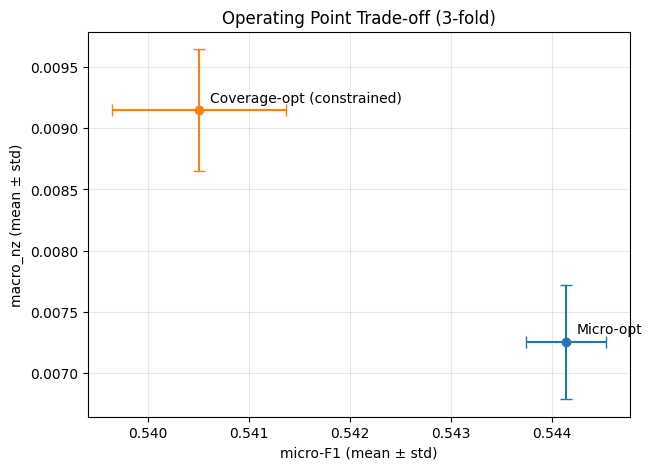

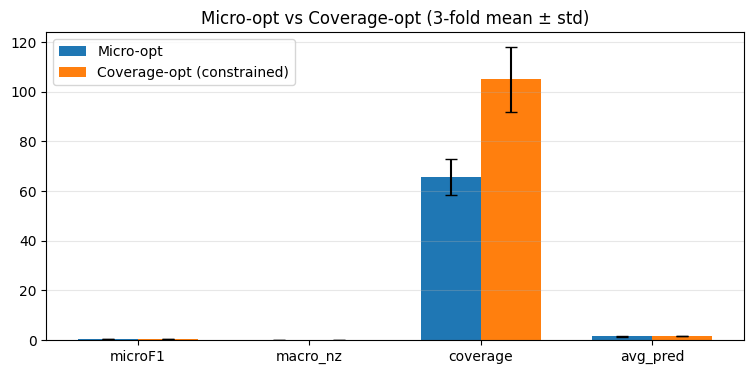

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1) Prepare summary stats ----------
# micro-opt from df_cal (already computed)
micro_opt = df_cal[["fold","micro_opt_microF1","micro_opt_macro_nz","micro_opt_coverage","micro_opt_avg_pred"]].copy()
micro_opt.columns = ["fold","microF1","macro_nz","coverage","avg_pred"]
micro_opt["operating_point"] = "Micro-opt"

# coverage-opt FIXED from df_fixed (your fixed constrained table)
cov_opt = df_fixed[["fold","micro","macro_nz","coverage","avg_pred"]].copy()
cov_opt.columns = ["fold","microF1","macro_nz","coverage","avg_pred"]
cov_opt["operating_point"] = "Coverage-opt (constrained)"

all_points = pd.concat([micro_opt, cov_opt], ignore_index=True)

# mean ± std
summary = all_points.groupby("operating_point")[["microF1","macro_nz","coverage","avg_pred"]].agg(["mean","std"])
display(summary)

# ---------- 2) Improvements (coverage-opt vs micro-opt) ----------
m_micro = float(summary.loc["Micro-opt", ("microF1","mean")])
m_cov   = float(summary.loc["Coverage-opt (constrained)", ("microF1","mean")])

m_macro = float(summary.loc["Micro-opt", ("macro_nz","mean")])
c_macro = float(summary.loc["Coverage-opt (constrained)", ("macro_nz","mean")])

m_covg  = float(summary.loc["Micro-opt", ("coverage","mean")])
c_covg  = float(summary.loc["Coverage-opt (constrained)", ("coverage","mean")])

m_avg   = float(summary.loc["Micro-opt", ("avg_pred","mean")])
c_avg   = float(summary.loc["Coverage-opt (constrained)", ("avg_pred","mean")])

delta_micro = m_cov - m_micro
delta_macro = c_macro - m_macro
delta_covg  = c_covg - m_covg
delta_avg   = c_avg - m_avg

print("=== Key deltas (Coverage-opt minus Micro-opt) ===")
print(f"Δ microF1   = {delta_micro:+.4f} (drop expected, constrained)")
print(f"Δ macro_nz  = {delta_macro:+.4f}  ({(delta_macro/m_macro*100):+.1f}% relative)")
print(f"Δ coverage  = {delta_covg:+.1f} labels hit  ({(delta_covg/m_covg*100):+.1f}% relative)")
print(f"Δ avg_pred  = {delta_avg:+.2f} labels/image")

# ---------- 3) Plot 1: Trade-off (micro vs macro_nz) with error bars ----------
micro_mean = [float(summary.loc["Micro-opt", ("microF1","mean")]),
              float(summary.loc["Coverage-opt (constrained)", ("microF1","mean")])]
micro_std  = [float(summary.loc["Micro-opt", ("microF1","std")]),
              float(summary.loc["Coverage-opt (constrained)", ("microF1","std")])]

macro_mean = [float(summary.loc["Micro-opt", ("macro_nz","mean")]),
              float(summary.loc["Coverage-opt (constrained)", ("macro_nz","mean")])]
macro_std  = [float(summary.loc["Micro-opt", ("macro_nz","std")]),
              float(summary.loc["Coverage-opt (constrained)", ("macro_nz","std")])]

labels = ["Micro-opt", "Coverage-opt (constrained)"]

plt.figure(figsize=(7,5))
for i in range(2):
    plt.errorbar(micro_mean[i], macro_mean[i],
                 xerr=micro_std[i], yerr=macro_std[i],
                 fmt="o", capsize=4)
    plt.annotate(labels[i], (micro_mean[i], macro_mean[i]), textcoords="offset points", xytext=(8,6))
plt.xlabel("micro-F1 (mean ± std)")
plt.ylabel("macro_nz (mean ± std)")
plt.title("Operating Point Trade-off (3-fold)")
plt.grid(True, alpha=0.3)
plt.show()

# ---------- 4) Plot 2: Bar comparison with error bars ----------
metrics = ["microF1","macro_nz","coverage","avg_pred"]
means_micro = [float(summary.loc["Micro-opt", (m,"mean")]) for m in metrics]
stds_micro  = [float(summary.loc["Micro-opt", (m,"std")])  for m in metrics]
means_cov   = [float(summary.loc["Coverage-opt (constrained)", (m,"mean")]) for m in metrics]
stds_cov    = [float(summary.loc["Coverage-opt (constrained)", (m,"std")])  for m in metrics]

x = np.arange(len(metrics))
w = 0.35

plt.figure(figsize=(9,4))
plt.bar(x - w/2, means_micro, w, yerr=stds_micro, capsize=4, label="Micro-opt")
plt.bar(x + w/2, means_cov,   w, yerr=stds_cov,   capsize=4, label="Coverage-opt (constrained)")
plt.xticks(x, metrics)
plt.title("Micro-opt vs Coverage-opt (3-fold mean ± std)")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [42]:
import os
import numpy as np
import pandas as pd

def build_t_class(K, head_slices, thr_dict):
    """
    Build per-class threshold array (len=K) from per-head thresholds.
    thr_dict example: {'lt100':0.60, '100_500':0.55, '500_1000':0.55, 'gt1000':0.60}
    """
    t = np.full(K, 0.5, dtype=np.float32)
    for head_name, idxs in head_slices.items():
        t[idxs] = float(thr_dict[head_name])
    return t

def accumulate_counts_from_memmaps(Y_path, P_path, t_class, chunk=2048):
    """
    Compute per-class tp/fp/fn/support with chunking to avoid memory spikes.
    """
    Y = np.load(Y_path, mmap_mode="r")  # uint8 [N,K]
    P = np.load(P_path, mmap_mode="r")  # float32 [N,K]
    N, K_ = Y.shape
    assert K_ == len(t_class)

    tp = np.zeros(K_, dtype=np.int64)
    fp = np.zeros(K_, dtype=np.int64)
    fn = np.zeros(K_, dtype=np.int64)
    sup = np.zeros(K_, dtype=np.int64)

    for s in range(0, N, chunk):
        e = min(N, s+chunk)
        y = (Y[s:e].astype(np.uint8) > 0)
        p = (P[s:e] >= t_class)  # bool

        tp += np.logical_and(p, y).sum(axis=0).astype(np.int64)
        fp += np.logical_and(p, ~y).sum(axis=0).astype(np.int64)
        fn += np.logical_and(~p, y).sum(axis=0).astype(np.int64)
        sup += y.sum(axis=0).astype(np.int64)

    return tp, fp, fn, sup

def prf_from_counts(tp, fp, fn):
    P = tp / (tp + fp + 1e-12)
    R = tp / (tp + fn + 1e-12)
    F1 = (2*tp) / (2*tp + fp + fn + 1e-12)
    return P.astype(np.float32), R.astype(np.float32), F1.astype(np.float32)

# ---- Aggregate across folds for both operating points ----
tp_m = fp_m = fn_m = sup_m = None
tp_c = fp_c = fn_c = sup_c = None

for fold in [1,2,3]:
    Y_path = f"/content/fold{fold}_Y.npy"
    P_path = f"/content/fold{fold}_P.npy"
    assert os.path.exists(Y_path) and os.path.exists(P_path)

    head_slices = fold_head_slices[fold-1]  # dict: head -> np.array(idxs)

    # micro-opt thresholds for THIS fold
    t_micro = build_t_class(K, head_slices, thr_micro[fold])

    # coverage-opt FIXED thresholds for THIS fold
    # thr_cov_fixed uses head names as keys as printed
    # note: in our fixed cell we stored by head name -> float
    t_cov = build_t_class(K, head_slices, thr_cov_fixed[fold])

    tp, fp, fn, sup = accumulate_counts_from_memmaps(Y_path, P_path, t_micro)
    if tp_m is None:
        tp_m, fp_m, fn_m, sup_m = tp, fp, fn, sup
    else:
        tp_m += tp; fp_m += fp; fn_m += fn; sup_m += sup

    tp, fp, fn, sup = accumulate_counts_from_memmaps(Y_path, P_path, t_cov)
    if tp_c is None:
        tp_c, fp_c, fn_c, sup_c = tp, fp, fn, sup
    else:
        tp_c += tp; fp_c += fp; fn_c += fn; sup_c += sup

# ---- Compute per-class metrics ----
Pm, Rm, Fm = prf_from_counts(tp_m, fp_m, fn_m)
Pc, Rc, Fc = prf_from_counts(tp_c, fp_c, fn_c)

support = sup_m  # same GT support

# ---- Build dataframe ----
cuis = [idx2concept[i] for i in range(K)]  # CUI string
df_pc = pd.DataFrame({
    "CUI": cuis,
    "support": support,
    "P_microopt": Pm, "R_microopt": Rm, "F1_microopt": Fm,
    "P_covopt": Pc,   "R_covopt": Rc,   "F1_covopt": Fc,
})
df_pc["dF1"] = df_pc["F1_covopt"] - df_pc["F1_microopt"]
df_pc["dR"]  = df_pc["R_covopt"]  - df_pc["R_microopt"]

# ---- Top-200 by support (most important clinically/common) ----
df_top200 = df_pc.sort_values("support", ascending=False).head(200).reset_index(drop=True)
display(df_top200.head(20))

# Save files
csv_path = "/content/top200_per_class_microopt_vs_covopt.csv"
xlsx_path = "/content/top200_per_class_microopt_vs_covopt.xlsx"
df_top200.to_csv(csv_path, index=False)
df_top200.to_excel(xlsx_path, index=False)

print("✅ Saved:", csv_path)
print("✅ Saved:", xlsx_path)

# (Optional) download to laptop
from google.colab import files
files.download(csv_path)
files.download(xlsx_path)

,CUI,support,P_microopt,R_microopt,F1_microopt,P_covopt,R_covopt,F1_covopt,dF1,dR
0,C0040405,40992,0.968633,0.982338,0.975437,0.967368,0.982801,0.975024,-0.000414,0.000463
1,C1306645,31818,0.972056,0.980671,0.976345,0.970747,0.981426,0.976057,-0.000287,0.000754
2,C0024485,18587,0.947760,0.953623,0.950683,0.944060,0.955184,0.949589,-0.001093,0.001560
3,C0041618,17143,0.995455,0.996500,0.995977,0.995223,0.996500,0.995861,-0.000116,0.000000
4,C0817096,15066,0.764562,0.789327,0.776747,0.720612,0.818665,0.766515,-0.010232,0.029338
5,C0000726,6537,0.647538,0.498853,0.563553,0.596646,0.517057,0.554008,-0.009546,0.018204
6,C0002978,6055,0.855505,0.924030,0.888448,0.847603,0.928654,0.886279,-0.002168,0.004624
7,C0037303,5637,0.959302,0.936668,0.947850,0.954874,0.938442,0.946587,-0.001264,0.001774
8,C0030797,5342,0.510958,0.445152,0.475790,0.466496,0.476975,0.471677,-0.004113,0.031823
9,C0023216,4662,0.851281,0.912269,0.880721,0.845500,0.916774,0.879695,-0.001025,0.004505


✅ Saved: /content/top200_per_class_microopt_vs_covopt.csv
✅ Saved: /content/top200_per_class_microopt_vs_covopt.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# ===== Paper-ready summary text =====
m1 = float(summary.loc["Micro-opt", ("microF1","mean")])
s1 = float(summary.loc["Micro-opt", ("microF1","std")])
m2 = float(summary.loc["Micro-opt", ("macro_nz","mean")])
s2 = float(summary.loc["Micro-opt", ("macro_nz","std")])

c1 = float(summary.loc["Coverage-opt (constrained)", ("microF1","mean")])
cs1 = float(summary.loc["Coverage-opt (constrained)", ("microF1","std")])
c2 = float(summary.loc["Coverage-opt (constrained)", ("macro_nz","mean")])
cs2 = float(summary.loc["Coverage-opt (constrained)", ("macro_nz","std")])

cov_m = float(summary.loc["Micro-opt", ("coverage","mean")])
cov_c = float(summary.loc["Coverage-opt (constrained)", ("coverage","mean")])

print(
f"""
Final 3-fold results (mean ± std):
- Micro-opt operating point: micro-F1 = {m1:.4f} ± {s1:.4f}, macro_nz = {m2:.4f} ± {s2:.4f}.
- Coverage-opt (constrained) operating point: micro-F1 = {c1:.4f} ± {cs1:.4f}, macro_nz = {c2:.4f} ± {cs2:.4f}.

Trade-off:
- Coverage-opt improves macro_nz by {(c2-m2):+.4f} ({(c2-m2)/m2*100:+.1f}%) while keeping micro-F1 within {DELTA_MICRO:.3f} of micro-opt.
- Coverage (labels hit at least once) increases from ~{cov_m:.1f} to ~{cov_c:.1f} (+{(cov_c-cov_m):.1f}).
""".strip()
)

Final 3-fold results (mean ± std):
- Micro-opt operating point: micro-F1 = 0.5441 ± 0.0004, macro_nz = 0.0073 ± 0.0005.
- Coverage-opt (constrained) operating point: micro-F1 = 0.5405 ± 0.0009, macro_nz = 0.0091 ± 0.0005.

Trade-off:
- Coverage-opt improves macro_nz by +0.0019 (+26.1%) while keeping micro-F1 within 0.005 of micro-opt.
- Coverage (labels hit at least once) increases from ~65.7 to ~105.0 (+39.3).


In [44]:
import os
import numpy as np
import pandas as pd
from google.colab import files

EPS = 1e-12

def build_t_class(K, head_slices, thr_dict):
    """
    Build per-class threshold array (len=K) from per-head thresholds.
    thr_dict example keys: 'lt100','100_500','500_1000','gt1000'
    """
    t = np.full(K, 0.5, dtype=np.float32)
    for head_name, idxs in head_slices.items():
        t[idxs] = float(thr_dict[head_name])
    return t

def accumulate_counts_from_memmaps(Y_path, P_path, t_class, chunk=2048):
    """
    Compute per-class tp/fp/fn/support with chunking.
    """
    Y = np.load(Y_path, mmap_mode="r")  # uint8 [N,K]
    P = np.load(P_path, mmap_mode="r")  # float32 [N,K]
    N, K_ = Y.shape
    assert K_ == len(t_class)

    tp = np.zeros(K_, dtype=np.int64)
    fp = np.zeros(K_, dtype=np.int64)
    fn = np.zeros(K_, dtype=np.int64)
    sup = np.zeros(K_, dtype=np.int64)

    for s in range(0, N, chunk):
        e = min(N, s + chunk)
        y = (Y[s:e].astype(np.uint8) > 0)          # bool
        p = (P[s:e] >= t_class)                    # bool

        tp += np.logical_and(p, y).sum(axis=0).astype(np.int64)
        fp += np.logical_and(p, ~y).sum(axis=0).astype(np.int64)
        fn += np.logical_and(~p, y).sum(axis=0).astype(np.int64)
        sup += y.sum(axis=0).astype(np.int64)

    return tp, fp, fn, sup

def prf_from_counts(tp, fp, fn):
    prec = tp / (tp + fp + EPS)
    rec  = tp / (tp + fn + EPS)
    f1   = (2*tp) / (2*tp + fp + fn + EPS)
    return prec.astype(np.float32), rec.astype(np.float32), f1.astype(np.float32)

# ---------- Aggregate across folds ----------
tp_m = fp_m = fn_m = sup_m = None
tp_c = fp_c = fn_c = sup_c = None

for fold in [1, 2, 3]:
    Y_path = f"/content/fold{fold}_Y.npy"
    P_path = f"/content/fold{fold}_P.npy"
    assert os.path.exists(Y_path) and os.path.exists(P_path), f"Missing fold files for fold {fold}"

    head_slices = fold_head_slices[fold-1]  # dict head->np.array

    # micro-opt per fold thresholds
    t_micro = build_t_class(K, head_slices, thr_micro[fold])

    # coverage-opt FIXED per fold thresholds
    t_cov = build_t_class(K, head_slices, thr_cov_fixed[fold])

    tp, fp, fn, sup = accumulate_counts_from_memmaps(Y_path, P_path, t_micro, chunk=2048)
    if tp_m is None:
        tp_m, fp_m, fn_m, sup_m = tp, fp, fn, sup
    else:
        tp_m += tp; fp_m += fp; fn_m += fn; sup_m += sup

    tp, fp, fn, sup = accumulate_counts_from_memmaps(Y_path, P_path, t_cov, chunk=2048)
    if tp_c is None:
        tp_c, fp_c, fn_c, sup_c = tp, fp, fn, sup
    else:
        tp_c += tp; fp_c += fp; fn_c += fn; sup_c += sup

# ---------- Per-class metrics ----------
Pm, Rm, Fm = prf_from_counts(tp_m, fp_m, fn_m)
Pc, Rc, Fc = prf_from_counts(tp_c, fp_c, fn_c)

support = sup_m  # GT support (same)

cuis = [idx2concept[i] for i in range(K)]  # CUI strings

df_all = pd.DataFrame({
    "CUI": cuis,
    "support": support,
    "TP_microopt": tp_m, "FP_microopt": fp_m, "FN_microopt": fn_m,
    "P_microopt": Pm, "R_microopt": Rm, "F1_microopt": Fm,
    "TP_covopt": tp_c, "FP_covopt": fp_c, "FN_covopt": fn_c,
    "P_covopt": Pc, "R_covopt": Rc, "F1_covopt": Fc
})

df_all["dF1"] = df_all["F1_covopt"] - df_all["F1_microopt"]
df_all["dR"]  = df_all["R_covopt"]  - df_all["R_microopt"]

# Sort (اختيارياً): الأكثر شيوعاً أولاً
df_all = df_all.sort_values("support", ascending=False).reset_index(drop=True)

display(df_all.head(20))
print("Total classes:", len(df_all), "| K:", K)

# ---------- Save + Download ----------
csv_path  = "/content/per_class_microopt_vs_covopt_ALL.csv"
xlsx_path = "/content/per_class_microopt_vs_covopt_ALL.xlsx"

df_all.to_csv(csv_path, index=False)
df_all.to_excel(xlsx_path, index=False)

print("✅ Saved:", csv_path)
print("✅ Saved:", xlsx_path)

files.download(csv_path)
files.download(xlsx_path)

,CUI,support,TP_microopt,FP_microopt,FN_microopt,P_microopt,R_microopt,F1_microopt,TP_covopt,FP_covopt,FN_covopt,P_covopt,R_covopt,F1_covopt,dF1,dR
0,C0040405,40992,40268,1304,724,0.968633,0.982338,0.975437,40287,1359,705,0.967368,0.982801,0.975024,-0.000414,0.000463
1,C1306645,31818,31203,897,615,0.972056,0.980671,0.976345,31227,941,591,0.970747,0.981426,0.976057,-0.000287,0.000754
2,C0024485,18587,17725,977,862,0.947760,0.953623,0.950683,17754,1052,833,0.944060,0.955184,0.949589,-0.001093,0.001560
3,C0041618,17143,17083,78,60,0.995455,0.996500,0.995977,17083,82,60,0.995223,0.996500,0.995861,-0.000116,0.000000
4,C0817096,15066,11892,3662,3174,0.764562,0.789327,0.776747,12334,4782,2732,0.720612,0.818665,0.766515,-0.010232,0.029338
5,C0000726,6537,3261,1775,3276,0.647538,0.498853,0.563553,3380,2285,3157,0.596646,0.517057,0.554008,-0.009546,0.018204
6,C0002978,6055,5595,945,460,0.855505,0.924030,0.888448,5623,1011,432,0.847603,0.928654,0.886279,-0.002168,0.004624
7,C0037303,5637,5280,224,357,0.959302,0.936668,0.947850,5290,250,347,0.954874,0.938442,0.946587,-0.001264,0.001774
8,C0030797,5342,2378,2276,2964,0.510958,0.445152,0.475790,2548,2914,2794,0.466496,0.476975,0.471677,-0.004113,0.031823
9,C0023216,4662,4253,743,409,0.851281,0.912269,0.880721,4274,781,388,0.845500,0.916774,0.879695,-0.001025,0.004505


Total classes: 2646 | K: 2646
✅ Saved: /content/per_class_microopt_vs_covopt_ALL.csv
✅ Saved: /content/per_class_microopt_vs_covopt_ALL.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>